## Compare different budget terms in NoRad and CldRad experiments

### Import package

In [10]:
import h5py
import numpy as np

from typing import cast
from pathlib import Path
from scipy.interpolate import interp1d

from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

### Helper function

In [11]:
"""Apply daily mean to simulation result"""
def daily_mean(
    field: np.ndarray
) -> np.ndarray:
    
    field_daily: np.ndarray = np.stack([
        np.nanmean(field[..., 4*i:4*(i+1), :], axis=-2)
        for i in range(field.shape[-2]//4)
    ], axis=-2)

    return field_daily

### Load data

In [12]:
# Setup path for field data
HomePath: Path = Path("/home/b11209013/Kuang2008_v0.3.0/Config")
NoPath: Path = Path("/work/b11209013/Kuang2008_v0.3.0/full/Rad(0.0,0.0,0.0)/latest")
CldPath: Path = Path("/work/b11209013/Kuang2008_v0.3.0/full/Rad(0.0,0.0,0.1)/latest")
FigPath : Path = Path("/home/b11209013/Kuang2008_v0.3.0_Analysis/Figure/NoRad_vs_CldRad")

# Load growth rate data for identifying most-unstable mode
## Load growth rate
with h5py.File(NoPath / "EigenAnalysis.h5", "r") as file:
    No_GR: np.ndarray = cast(h5py.Dataset, file["GrowthRates"])[:, 0]
    k          : np.ndarray = cast(h5py.Dataset, file["k"])[...]

with h5py.File(CldPath / "EigenAnalysis.h5", "r") as file:
    Cld_GR: np.ndarray = cast(h5py.Dataset, file["GrowthRates"])[:, 0]

## identifying most unstable mode
Noidx       : int = np.argmax(No_GR).astype(int)
Cldidx      : int = np.argmax(Cld_GR).astype(int)
Nok         : float = k[Noidx]
Cldk        : float = k[Cldidx]

# Load Galerkin data
with h5py.File(NoPath / "GalerkinState.h5", "r") as file:
    NoState: dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, file[key])[Noidx, ...]
        for key in file.keys()
        if key.startswith(("w", "T", "J"))
    } # shape: (nz, nx, nt, nens)

    x: np.ndarray = cast(h5py.Dataset, file["x"])[...]
    z: np.ndarray = cast(h5py.Dataset, file["z"])[...]

with h5py.File(CldPath / "GalerkinState.h5", "r") as file:
    CldState: dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, file[key])[Cldidx, ...]
        for key in file.keys()
        if key.startswith(("w", "T", "J"))
    } # shape: (nz, nx, nt, nens)

# Load J1 state for identifying peak of signal
with h5py.File(NoPath / "FourierState.h5", "r") as file:
    NoJ1: np.ndarray = daily_mean(cast(h5py.Dataset, file["J1"])[Noidx, ...])

with h5py.File(CldPath / "FourierState.h5", "r") as file:
    CldJ1: np.ndarray = daily_mean(cast(h5py.Dataset, file["J1"])[Cldidx, ...])

### Combining fields

In [13]:
Now : np.ndarray = NoState["w1"] + NoState["w2"]
Cldw: np.ndarray = CldState["w1"] + CldState["w2"]

NoT : np.ndarray = NoState["T1"] + NoState["T2"]
CldT: np.ndarray = CldState["T1"] + CldState["T2"]

NoJ : np.ndarray = NoState["J1"] + NoState["J2"]
CldJ: np.ndarray = CldState["J1"] + CldState["J2"]

### Calculate EAPE budget terms

In [14]:
NoGen : np.ndarray = NoJ * NoT
CldGen: np.ndarray = CldJ * CldT

NoDis : np.ndarray = -Now * NoT * (9.81/1004.5 - 0.0065)
CldDis : np.ndarray = -Cldw * CldT * (9.81/1004.5 - 0.0065)

### Composite

In [15]:
# select the 7-th day and the first ensemble
day: int = 6

NoGenSelect : np.ndarray = daily_mean(NoGen)[..., day, :][..., 0]
NoDisSelect : np.ndarray = daily_mean(NoDis)[..., day, :][..., 0]
NoJSelect   : np.ndarray = daily_mean(NoJ)[..., day, :][..., 0]
NoJ1Select  : np.ndarray = NoJ1[..., day, :][..., 0]

CldGenSelect: np.ndarray = daily_mean(CldGen)[..., day, :][..., 0]
CldDisSelect: np.ndarray = daily_mean(CldDis)[..., day, :][..., 0]
CldJSelect  : np.ndarray = daily_mean(CldJ)[..., day, :][..., 0]
CldJ1Select : np.ndarray = CldJ1[..., day, :][..., 0]

nz, nx = NoGenSelect.shape

# Roll field to the center of x domain
## Calculate shift
Noshift : int = (nx//2) - np.argmax(NoJ1Select, axis=0)
Cldshift: int = (nx//2) - np.argmax(CldJ1Select, axis=0)

## Rolling data
NoGenRoll: np.ndarray = np.roll(NoGenSelect, Noshift, axis=1)
NoDisRoll: np.ndarray = np.roll(NoDisSelect, Noshift, axis=1)
NoJRoll: np.ndarray = np.roll(NoJSelect, Noshift, axis=1)

CldGenRoll: np.ndarray = np.roll(CldGenSelect, Cldshift, axis=1)
CldDisRoll: np.ndarray = np.roll(CldDisSelect, Cldshift, axis=1)
CldJRoll: np.ndarray = np.roll(CldJSelect, Cldshift, axis=1)

### Calculate index for period

In [16]:
# Half grid
Nohalf_period     : float = (2*np.pi*4.32e6 / Nok) / 2
Nohalf_grid_points: int = int(Nohalf_period / (x[1] - x[0]))

Cldhalf_period     : float = (2*np.pi*4.32e6 / Cldk) / 2
Cldhalf_grid_points: int = int(Cldhalf_period / (x[1] - x[0]))


# Calculate period
Nopi_neg: int = int((nx//2) - Nohalf_grid_points//2)
Nopi_pos: int = int((nx//2) + 3*Nohalf_grid_points//2)

Cldpi_neg: int = int((nx//2) - Cldhalf_grid_points//2)
Cldpi_pos: int = int((nx//2) + 3*Cldhalf_grid_points//2)

Nogrid_length: int         = Nopi_pos - Nopi_neg
Nophase      : np.ndarray  = np.linspace(-np.pi, np.pi, Nogrid_length)

Cldgrid_length: int        = Cldpi_pos - Cldpi_neg
Cldphase      : np.ndarray = np.linspace(-np.pi, np.pi, Cldgrid_length)

### Regrid CldRad to NoRad experiment

In [17]:
CldGen_itp: np.ndarray = interp1d(Cldphase, CldGenRoll[:, Cldpi_neg:Cldpi_pos], axis=1)(Nophase)
CldDis_itp: np.ndarray = interp1d(Cldphase, CldDisRoll[:, Cldpi_neg:Cldpi_pos], axis=1)(Nophase)
CldJ_itp  : np.ndarray = interp1d(Cldphase, CldJRoll[:, Cldpi_neg:Cldpi_pos], axis=1)(Nophase)

### Visualization

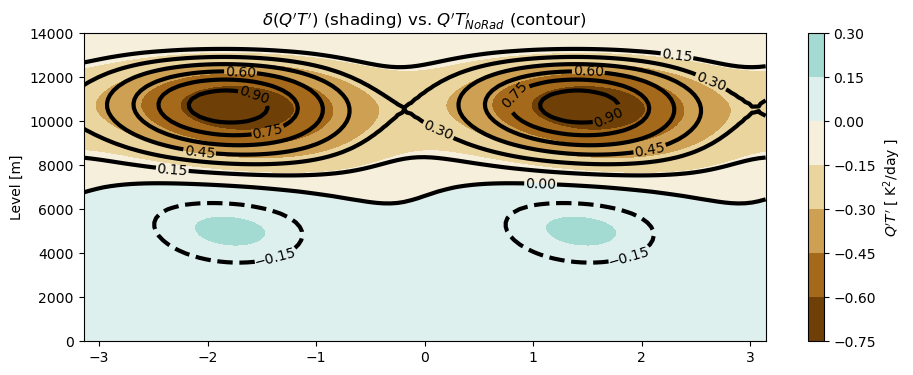

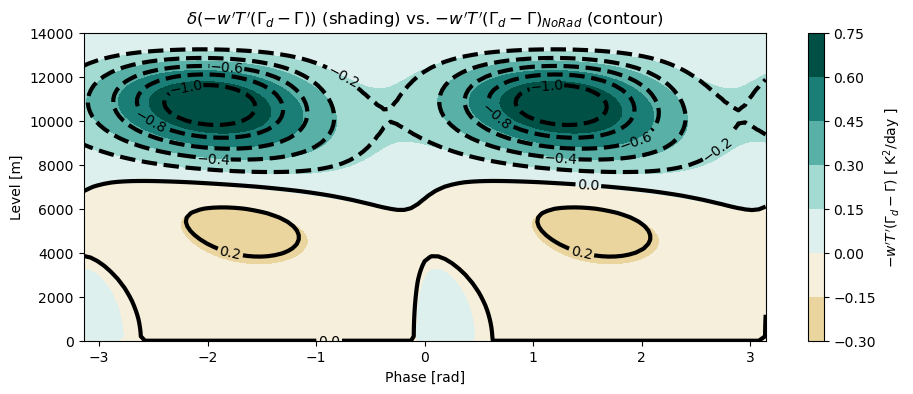

In [18]:
# Calculate difference between CldRad and NoRad
GenDiff: np.ndarray = CldGen_itp - NoGenRoll[:, Nopi_neg:Nopi_pos]
DisDiff: np.ndarray = CldDis_itp - NoDisRoll[:, Nopi_neg:Nopi_pos]

# Calculate the upper bound of colorbar
max_bound = np.max([np.nanmax(np.abs(GenDiff)), np.nanmax(np.abs(DisDiff))])

fig, ax = plt.subplots(1, 1, figsize=(11, 4), sharex=True)

gen_ctf = ax.contourf(
    Nophase, z, GenDiff,
    cmap="BrBG", norm=TwoSlopeNorm(vcenter=0, vmin=-max_bound, vmax=max_bound)
)
nogen_ct = ax.contour(
    Nophase, z, NoGenRoll[:, Nopi_neg:Nopi_pos],
    colors="black", linewidths=3
)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, 14000)
ax.set_ylabel("Level [m]")
ax.set_title(r"$\delta (Q^\prime T^\prime)$ (shading) vs. $Q^\prime T^\prime_{NoRad}$ (contour)")
ax.clabel(nogen_ct, inline=True)
fig.colorbar(gen_ctf, ax=ax, label=r"$Q^\prime T^\prime$ [ K$^2$/day ]")

plt.savefig(
    FigPath / "GenDiff.png",
    dpi=600, bbox_inches="tight"
    )
plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 1, figsize=(11, 4), sharex=True)

dis_ctf = ax.contourf(
    Nophase, z, DisDiff,
    cmap="BrBG", norm=TwoSlopeNorm(vcenter=0, vmin=-max_bound, vmax=max_bound)
)
nodis_ct = ax.contour(
    Nophase, z, NoDisRoll[:, Nopi_neg:Nopi_pos],
    colors="black", linewidths=3
)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, 14000)
ax.set_xlabel("Phase [rad]")
ax.set_ylabel("Level [m]")
ax.set_title(r"$\delta (-w^\prime T^\prime (\Gamma_d - \Gamma))$ (shading) vs. $-w^\prime T^\prime (\Gamma_d - \Gamma)_{NoRad}$ (contour)")
ax.clabel(nodis_ct, inline=True)
fig.colorbar(dis_ctf, ax=ax, label=r"$-w^\prime T^\prime (\Gamma_d - \Gamma)$ [ K$^2$/day ]")

plt.savefig(
    FigPath / "DisDiff.png",
    dpi=600, bbox_inches="tight"
    )
plt.show()
plt.close(fig)